In [80]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import os
import re

### Functions


In [84]:
def graph_matrix_indTFs(sets_list, num_regions, upregulated_names):
    all_numbers = sorted(set().union(*sets_list.values(), range(1, num_regions + 1)))
    
    binary_matrix = np.array([[int(num in s) for num in all_numbers] for s in sets_list.values()])
    df = pd.DataFrame(binary_matrix, index=sets_list.keys(), columns=all_numbers)
    
    rank_labels = [str(n) if n % 1000 == 1 else "" for n in all_numbers]
    df = df.loc[upregulated_names + list(set(sets_list.keys()) - set(upregulated_names))]
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(df, cmap=["white", "black"], cbar=False, xticklabels=rank_labels)
    plt.title("Set Membership Heatmap")
    plt.show()



def get_LE_bids_DE(TFs_use, temp_dir, rank_df):
    num_regions = len(rank_df)
    
    mu500_MB_list, mu500_SE_list = {}, {}
    mu_MB_list, mu_SE_list = {}, {}
    
    for _, row in TFs_use.iterrows():
        TF_motif, E_score, MB_LE, SE_LE = row["#TF"], row["E-Score"], row["MB_LE"], row["SE_LE"]
        
        dis_df = pd.read_csv(os.path.join(temp_dir, f"withAUC{TF_motif}__dis_andmore.csv"))
        dis_df.columns = ["Rank", "distances", "distances_abs",  "score",  "normalized_score",  "cumscore"]
        motif = dis_df[dis_df['distances'] != "."]
        motif['distances_abs'] = motif['distances_abs'].astype(float)
        mu500 = motif[motif["distances_abs"] < 501]["Rank"].tolist()
        motif = motif["Rank"].tolist()
        
        if E_score > 0:
            mu500_MB_list[TF_motif] = [m for m in mu500 if m < MB_LE]
            mu500_SE_list[TF_motif] = [m for m in mu500 if m < SE_LE]
            mu_MB_list[TF_motif] = [m for m in motif if m < MB_LE]
            mu_SE_list[TF_motif] = [m for m in motif if m < SE_LE]
        else:
            MB_LE, SE_LE = num_regions - MB_LE, num_regions - SE_LE
            mu500_MB_list[TF_motif] = [m for m in mu500 if m > MB_LE]
            mu500_SE_list[TF_motif] = [m for m in mu500 if m > SE_LE]
            mu_MB_list[TF_motif] = [m for m in motif if m > MB_LE]
            mu_SE_list[TF_motif] = [m for m in motif if m > SE_LE]
    plot_set_support_histogram(mu500_SE_list, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Stalled_Enrich Motif w/n 500bp", 
                              "./SE_Motif500bp.png")
    plot_set_support_histogram(mu500_MB_list, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Match_Background Motif w/n 500bp", 
                              "./SE_Motif1500bp.png")
    plot_set_support_histogram(mu_SE_list, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Stalled_Enrich Motif w/n 1.5kb", 
                              "./MB_Motif500bp.png")
    plot_set_support_histogram(mu_MB_list, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Match_Background Motif w/n 1.5kb", 
                              "./MB_Motif1500bp.png")
    #graph_matrix_full(mu500_SE_list, num_regions, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Stalled_Enrich mu500", [0.75, 1])
    # graph_matrix_full(mu500_MB_list, num_regions, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Match Background mu500", [0.75, 1])
    # graph_matrix_full(mu_SE_list, num_regions, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Stalled_Enrich", [0.75, 1])
    # graph_matrix_full(mu_MB_list, num_regions, TFs_use[TFs_use["E-Score"] > 0]["#TF"].tolist(), "Match Background", [0.75, 1])
    
    return {"mu500_MB": mu500_MB_list, "mu500_SE": mu500_SE_list, "mu_MB": mu_MB_list, "mu_SE": mu_SE_list}

def save_union_calls(LE_DE_lists, rank_df, file_save):
    rank_df["mu"] = (rank_df["start"] + rank_df["stop"]) // 2
    rank_df["name"] = rank_df["#chrom"] + ":" + rank_df["mu"].astype(str)
    mu500_SE_Ranks =  sum(LE_DE_lists["mu500_SE"].values(), [])
    mu_SE_Ranks =  sum(LE_DE_lists["mu_SE"].values(), [])
    mu500_MB_Ranks =  sum(LE_DE_lists["mu500_MB"].values(), [])
    mu_MB_Ranks =  sum(LE_DE_lists["mu_MB"].values(), [])
    LE_add = {
       
        "mu500_SE_all": rank_df.loc[mu500_SE_Ranks]["name"].tolist(),
        "mu_SE_all": rank_df.loc[mu_SE_Ranks]["name"].tolist(),
        "mu500_MB_all": rank_df.loc[mu500_MB_Ranks]["name"].tolist(),
        "mu_MB_all": rank_df.loc[mu_MB_Ranks]["name"].tolist()
    }
    #pd.to_pickle(LE_add, file_save)
    df = pd.DataFrame.from_dict(LE_add, orient="index")
    df.to_csv(file_save)

def get_TFs_for_LEDE(res, Escore_cutoff, Padj_cutoff, num_events_cutoff):
    # Extract the general TF for easier understanding
    res['Gen_TF'] = res['#TF'].apply(lambda x: re.split(r'\.', x)[0])
    
    # Filter results based on criteria
    res = res[(res["Frac Abv Null"] < 0.5)]
    sig_res_larger = res[(res['Corrected E-Score'].abs() > Escore_cutoff) & (res['Corrected P-adj'] < Padj_cutoff)]
    print(f"\nNumber of TF (Motifs) with a |Corrected Escore| > {Escore_cutoff} and Corrected Padj < {Padj_cutoff}: {sig_res_larger['#TF'].nunique()}\tNumber TFs: {sig_res_larger['Gen_TF'].nunique()}")
    
    TFs_use = res[(res['Corrected E-Score'].abs() > Escore_cutoff) & (res['Corrected P-adj'] < Padj_cutoff) & (res['Events'] < num_events_cutoff)]
    print(f"\nNumber of TF (Motifs) with a |Corrected Escore| > {Escore_cutoff} and Corrected Padj < {Padj_cutoff} AND Num motifs < {num_events_cutoff}: {TFs_use['#TF'].nunique()}\tNumber TFs: {TFs_use['Gen_TF'].nunique()}")
    
    return TFs_use



def plot_set_support_histogram(sets_list, upregulated_names, title="Histogram of Set Support", save_path=None):
    upregulated_sets = {k: v for k, v in sets_list.items() if k in upregulated_names}
    downregulated_sets = {k: v for k, v in sets_list.items() if k not in upregulated_names}

    num_up_regions = len(set(sum(upregulated_sets.values(), [])))
    num_down_regions = len(set(sum(downregulated_sets.values(), [])))
    # Count how many sets contain each number
    up_number_support = Counter(num for s in upregulated_sets.values() for num in s)
    down_number_support = Counter(num for s in downregulated_sets.values() for num in s)
    
    # Bin counts, grouping anything >10 into "10+"
    def bin_counts(counts):
        binned_counts = Counter({k if k <= 10 else "10+": v for k, v in counts.items()})
        return pd.DataFrame(binned_counts.items(), columns=["Sets Supporting", "Count"]).sort_values(
            by="Sets Supporting", key=lambda x: x.map(lambda v: int(v) if v != "10+" else 11)
        )
    
    up_df = bin_counts(Counter(up_number_support.values()))
    down_df = bin_counts(Counter(down_number_support.values()))

    # Get total number of sets in each category
    total_up_sets = len(upregulated_sets)
    total_down_sets = len(downregulated_sets)
    width = min(10, 0.7 * max(total_up_sets, total_down_sets))

    # Create subplots
    fig, axes = plt.subplots(2, 1, figsize=(width, 4), sharex=True, gridspec_kw={'height_ratios': [1, 1]})

    # Function to add bar labels while keeping them inside the plot
    def add_bar_labels(ax, num_regions):
        ylim = ax.get_ylim()[1]  # Get y-axis limit to prevent text overflow
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                # Calculate percentage
                percentage = (height / num_regions) * 100
                # If the text would go outside the plot, place it inside the bar
                text_y = height + (0.05 * ylim) if height < (0.85 * ylim) else height - (0.05 * ylim)
                text_color = "black"
                ax.text(
                    bar.get_x() + bar.get_width() / 2, text_y, f"{round(percentage, 1)}%",
                    ha='center', va='bottom' if height < (0.85 * ylim) else 'top',
                    fontsize=10, fontweight='bold', color=text_color
                )

    # Upregulated histogram
    sns.barplot(data=up_df, x="Sets Supporting", y="Count", color="lightgreen", ax=axes[0])
    axes[0].set_title(f"Upregulated (Total Sets: {total_up_sets})")
    axes[0].set_ylabel("# tREs")
    axes[0].tick_params(axis='x', rotation=90)
    add_bar_labels(axes[0], num_up_regions)  # Add percentage labels

    # Downregulated histogram
    sns.barplot(data=down_df, x="Sets Supporting", y="Count", color="lightblue", ax=axes[1])
    axes[1].set_title(f"Downregulated (Total Sets: {total_down_sets})")
    axes[1].set_xlabel("Number of TFs Supporting")
    axes[1].set_ylabel("# tREs")
    axes[1].tick_params(axis='x', rotation=90)  # Ensure x-ticks are visible and rotated
    add_bar_labels(axes[1], num_down_regions)  # Add percentage labels

    # Overall title
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    
    plt.show()


def main_LE_DE(res_file, ranked_file, temp_dir, Escore_cutoff=0.1, Padj_cutoff=1e-10, num_events_cutoff=15000, file_save=""):
    print("READING IN FILES")
    rank_df = pd.read_csv(ranked_file, sep="\t")
    res = pd.read_csv(res_file, sep="\t", index_col=False)
    res["Corrected P-adj"] = res["Corrected P-adj"].astype(float)
    print("GETTING TFS TO USE using |Escore| >", Escore_cutoff, "; Corrected Padj <", Padj_cutoff, "; Events <", num_events_cutoff)
    TFs_use = get_TFs_for_LEDE(res, Escore_cutoff, Padj_cutoff, num_events_cutoff)
    print("GETTING FINAL LE DE BIDS")
    LE_DE_lists = get_LE_bids_DE(TFs_use, temp_dir, rank_df)
    if not file_save:
        file_save = os.path.join(temp_dir, "LE_DE_motif.csv")
    print("SAVING FINAL CALLS")
    save_union_calls(LE_DE_lists, rank_df, file_save)

### Example Implementation

READING IN FILES
GETTING TFS TO USE using |Escore| > 0.1 ; Corrected Padj < 1e-10 ; Events < 15000

Number of TF (Motifs) with a |Corrected Escore| > 0.1 and Corrected Padj < 1e-10: 56	Number TFs: 47

Number of TF (Motifs) with a |Corrected Escore| > 0.1 and Corrected Padj < 1e-10 AND Num motifs < 15000: 55	Number TFs: 46
GETTING FINAL LE DE BIDS


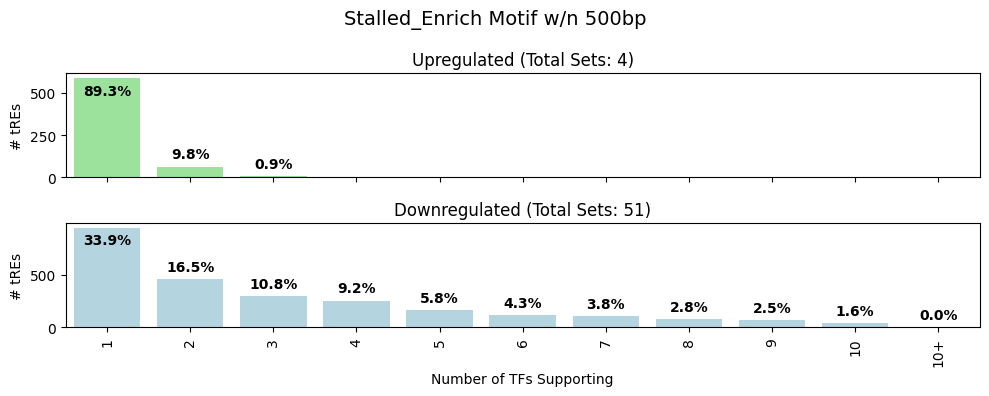

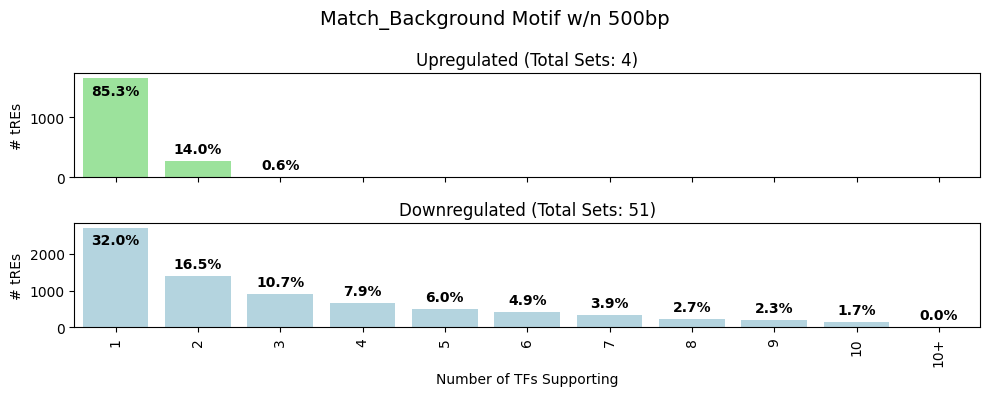

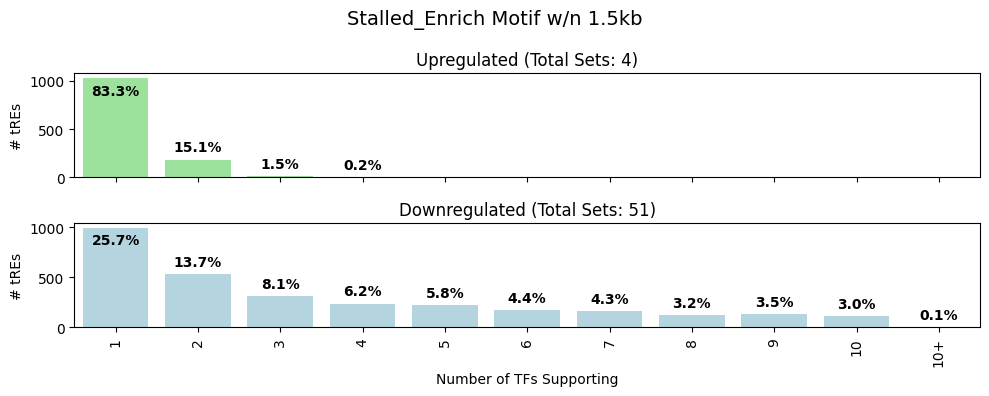

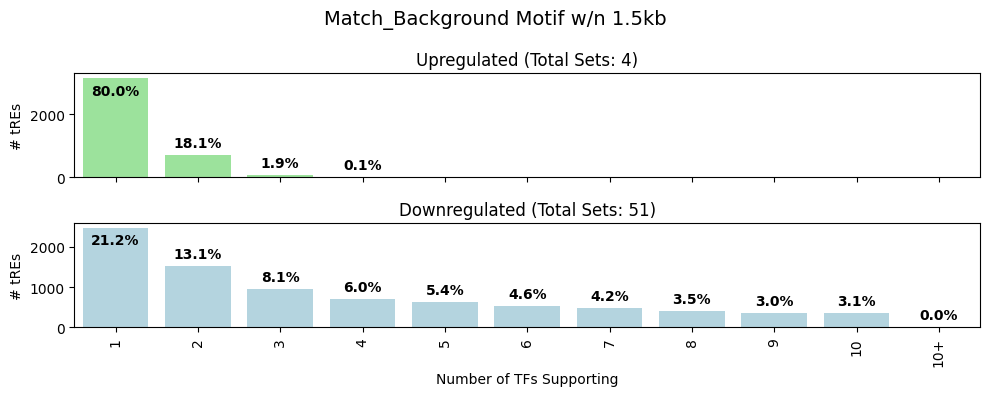

SAVING FINAL CALLS


In [85]:
res_file="/scratch/Users/hoto7260/Resp_Env/WSP_B2B/TFEA/out/WSP30_Veh_HK_thresh_AHR/results.txt"
ranked_file = "/Users/hoto7260/projects/Resp_Env/WSP_B2B/data/TFEA_input/EdgeR/NonTSS_WSP30vsVeh_QL_HK.txt"
temp_dir = "/scratch/Users/hoto7260/Resp_Env/WSP_B2B/TFEA/out/WSP30_Veh_HK_thresh_AHR/temp_files/"
check = main_LE_DE(res_file, ranked_file, temp_dir, file_save="./WSP30_LEDEadd_2.25.csv")